# Mapeamento

O mapeamento de reads curtas contra um genoma de referência é uma etapa fundamental nas análises genômicas, permitindo identificar a posição genômica exata de cada sequência obtida por tecnologias de sequenciamento de nova geração (NGS). Essa etapa é essencial para investigações como a detecção de variantes, estimativas de cobertura e análises de expressão gênica. Para essa tarefa, uma das ferramentas mais utilizadas é o BWA (Burrows-Wheeler Aligner), que realiza o alinhamento eficiente das sequências ao genoma de referência previamente indexado. Após o alinhamento, os resultados são gerados no formato SAM, que pode ser convertido e manipulado com o uso do SAMtools, uma suíte de programas voltada ao processamento de arquivos SAM/BAM. O SAMtools permite converter o arquivo para o formato binário BAM, ordenar os alinhamentos, indexar o arquivo resultante e extrair estatísticas relevantes. Esse fluxo de trabalho, que combina rapidez, precisão e compatibilidade com outras ferramentas bioinformáticas, é amplamente empregado em projetos de genômica comparativa, genética populacional e estudos de conservação.




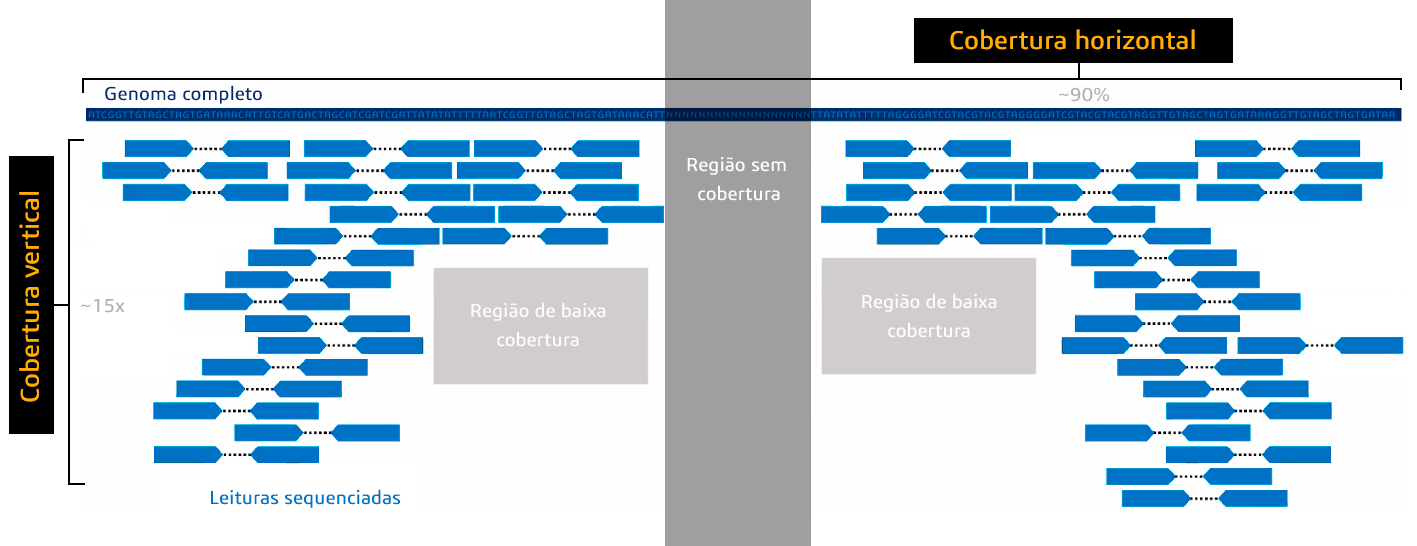

---
## Seção 1: Preparação do ambiente do Google Colab

Para que os tutoriais funcionem de forma adequada é necessário dar acesso ao Google Drive, onde arquivos e scripts estão localizados, bem como a instalação do Conda e dos pacotes que serão utilizados. Esses passos são necessários sempre que ocorrer algum período de inatividade ou começo de nova aula prática.
Use comandos básicos do UNIX para explorar os dados e se familiarizar com o formato FASTQ.

In [ ]:
# Habilitar o acesso ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Criação de uma variável para o diretório base
base_dir = "drive/MyDrive/PopGen_UFMG_2026"


Mounted at /content/drive


In [ ]:
# Instalar Miniconda (1–2 min)
import os

miniconda_installer = f"{base_dir}/miniconda/Miniconda3-latest-Linux-x86_64.sh"
if not os.path.exists(miniconda_installer):
    !wget -P "{base_dir}/miniconda" https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh

!bash "{miniconda_installer}" -bfp /usr/local

# Add conda to the environment
import os
os.environ['PATH'] = '/usr/local/bin:' + os.environ['PATH']

!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [ ]:
# Criação do ambiente Conda e instalação dos programas necessários
!conda create -n mapping -c bioconda -c conda-forge -y bwa samtools

# Ative o ambiente
!conda run -n mapping

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ done
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: \ | done

## Package Plan ##

  environment location: /usr/local/envs/mapping

  added / updated specs:
    - bwa
    - samtools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bwa-0.7.19                 |       h577a1d6_1         639 KB  bioconda
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.5.20  |       hbd8a1cb_0         127 KB  conda-forge
    htslib-1.23.1              |       h633afcb_0         1.1 MB  bioconda
    keyutils-1.6.3             |       hb9d3cd8_0         131 KB  conda-forge
   

---
## Seção 2: Mapeamento


📝 **Exercícios:**

Vamos mapear as reads do indivíduo BT04 no genoma de referência da preguiça de coleira (*Bradypus torquatus*).





### **1)** Primeiramente, vamos nos familiarizar com o genoma de referência.

> ❓Quantas e quais sequências estão presentes no arquivo `fasta` que usaremos como referência?

In [ ]:
!grep "^>" drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta

>manual_scaffold_14
>manual_scaffold_15


Temos apenas 2 scaffolds: scaffold 14 e 15. Limitamos este arquivo fasta a estes 2 scaffolds por limitações de tempo e recurso nesta prática.




### **2)** Indexação da referência
Para que o `bwa` funcione, precisamos indexar a referência. Este processo cria um índice do genoma de referência para acelerar o alinhamento posterior. Para isso use o comando `bwa index` seguido do genoma de referência.

In [ ]:
!conda run -n mapping bash -c \
"bwa index drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta"


[bwa_index] Pack FASTA... 2.21 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=393018524, availableWord=39654092
[BWTIncConstructFromPacked] 10 iterations done. 65411740 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 120844188 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 170108684 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 213891068 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 252800924 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 287380076 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 318110076 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 345418956 characters processed.
[BWTIncConstructFromPacked] 90 iterations done. 369687148 characters processed.
[BWTIncConstructFromPacked] 100 iterations done. 391252732 characters processed.
[bwt_gen] Finished constructing BWT in 101 iteration

### **3)** Mapeamento

Agora vamos correr o `bwa mem` para mapear as reads do indivíduo BT04 a esta referência.

In [ ]:
!conda run -n mapping bash -c \
"bwa mem -t 2 drive/MyDrive/PopGen_UFMG_2026/Material/reference/reference_genome_chr_14_15.fasta \
     drive/MyDrive/PopGen_UFMG_2026/Material/raw_fastq/BT04.R1.fq.gz drive/MyDrive/PopGen_UFMG_2026/Material/raw_fastq/BT04.R2.fq.gz | \
     samtools view -Sb - | \
     samtools sort -o drive/MyDrive/PopGen_UFMG_2026/analyses/02_Mapping/BT04.bam -"

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133340 sequences (20000099 bp)...
[M::process] read 133340 sequences (20000268 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (0, 4572, 11, 0)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (309, 360, 413)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (101, 621)
[M::mem_pestat] mean and std.dev: (361.27, 79.69)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 725)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) percentile: (2608, 3337, 5451)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 11137)
[M::mem_pestat] mean and std.dev: (3818.27, 1793.15)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 13980)
[M::mem_pestat] skip orientation RR

Explicação:

* `bwa mem` → algoritmo de alinhamento para alinhar reads com base na similaridade das sequências
* `-t` → número de threads
* `samtools view` → converte, filtra e visualiza arquivos SAM/BAM/CRAM.
* `-S` → indica que a entrada está no formato SAM
* `-b` → especifica que a saída deve ser no formato BAM (binário compactado).
* `-` (como argumento final) → significa que a entrada será lida da entrada padrão (stdin), e a saída será escrita na saída padrão (stdout).



### **4)** Visualização
Visualize o output `bam` usando o `samtools`.

In [ ]:
!conda run -n mapping bash -c \
"samtools view drive/MyDrive/PopGen_UFMG_2026/analyses/02_Mapping/BT04.bam | head"

Certifique-se que você entende todos os campos do formato `bam` com a ajuda da figura abaixo.

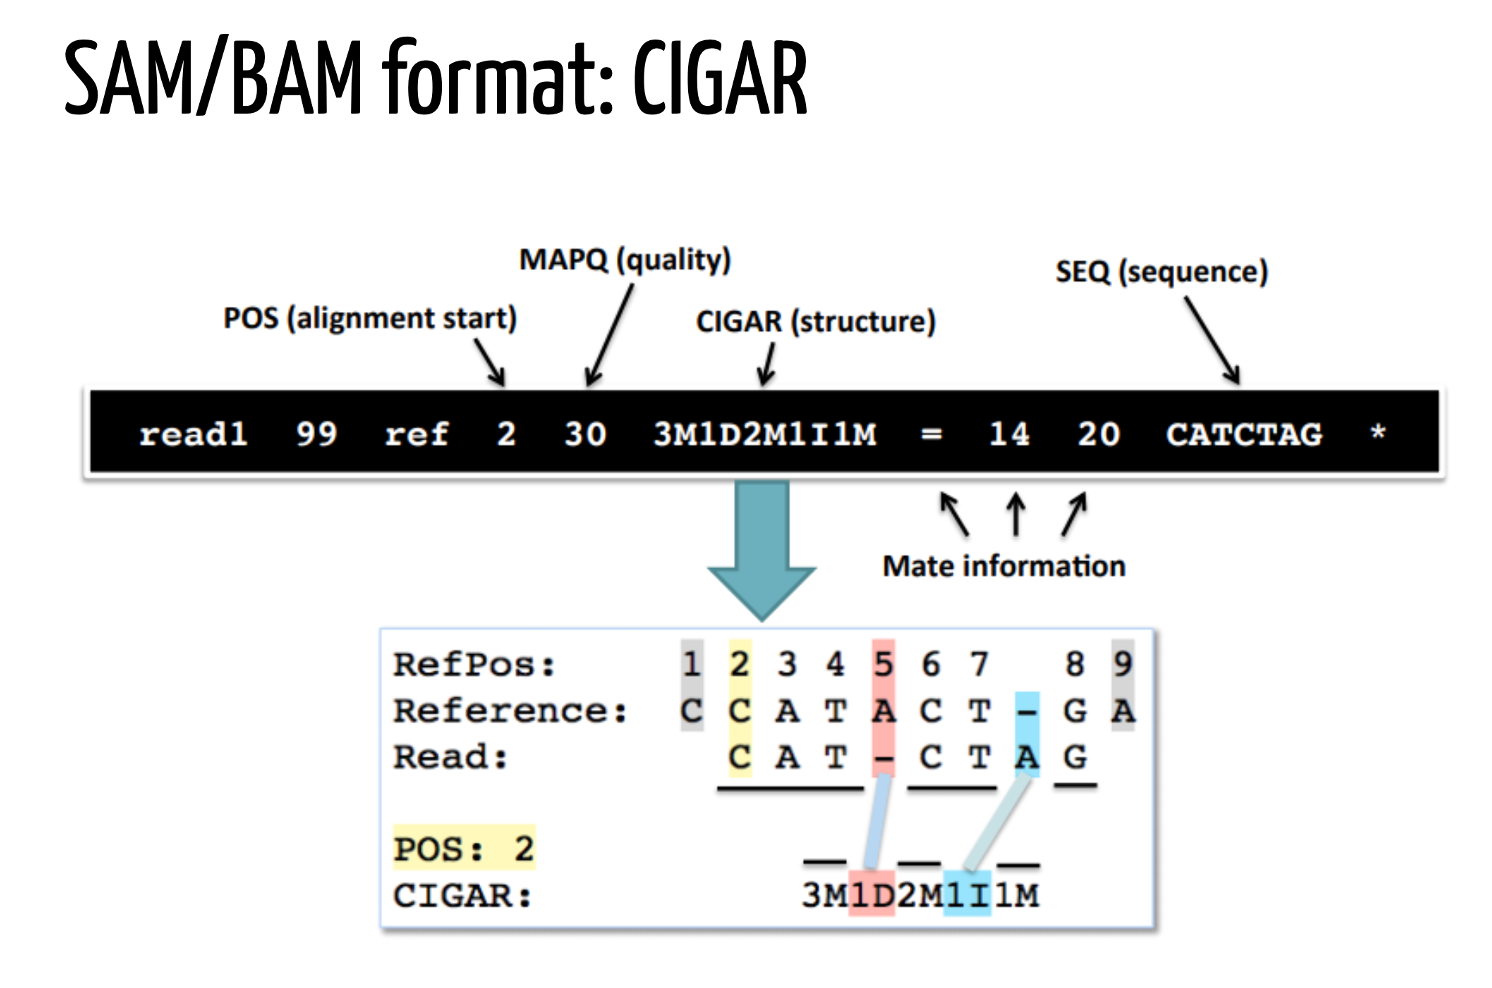


MAPQ: Qualidade do mapeamento -> probabilidade de que a read esteja desalinhada no arquivo BAM.
* Relatada de 0 a 255, com um número menor indicando maior qualidade.
* Score MAPQ 20: a probabilidade de uma read mapeada corretamente é de 0,99.
* Score MAPQ 30: a probabilidade de uma read mapeada corretamente é de 0,999.

Score CIGAR -> representação compactada do alinhamento (Compact Idiosyncratic Gapped Alignment Report).



### **5)** Check as estatísticas básicas do `bam`

Use o comando `samtools flagstat` para gerar estatísticas rápidas de alinhamentos do arquivo `bam`.

In [ ]:
!conda run -n mapping bash -c \
"samtools flagstat drive/MyDrive/PopGen_UFMG_2026/analyses/02_Mapping/BT04.bam"

### **6)** Cobertura

Vamos calcular a cobertura do nosso arquivo bam. A cobertura (depth) é o número médio de leituras que se alinham a uma posição específica no genoma de referência.

In [ ]:
!conda run -n mapping bash -c \
"samtools depth drive/MyDrive/PopGen_UFMG_2026/analyses/02_Mapping/BT04.bam | awk '{sum+=\$3} END {print sum/NR}'"

2.68537


Explicação:

* `samtools flagstat` Para cada posição coberta no genoma, imprime uma linha com 3 colunas: `cromossomo   posição   cobertura`
* `awk '{sum+=\$3}` → soma os valores da 3ª coluna (a cobertura em cada posição).
* `END { ... }` → no final do arquivo, executa esse bloco.
* `{print sum/NR}` → imprime a média da cobertura (soma total / número de posições).
* `NR` → número de linhas lidas (ou seja, número de posições).



>❓ Como você avalia a cobertura desta amostra? Você considera esta cobertura boa o suficiente para prosseguir para o SNP calling deste indivíduo?

### **7)** Visualizando o mapping

Existem alguns programas onde podemos visualizar os alinhamentos das reads ao longo dos cromossomos, alguns incluindo o `Integrative Genome Viewer (IGV)` e o `tview` no samtools.

Para visualizar algumas leituras do alinhamento, utilizaremos o IGV (Integrative Genomics Viewer), disponível em https://igv.org/doc/desktop/#DownloadPage.Para usar esse software no seu computador, é necessário baixar e instalar o IGV.

Devido à limitação de tempo neste tutorial, não faremos a instalação completa em aula. Em vez disso, apresentaremos um passo a passo ilustrado com capturas de tela, que servirá como guia para que você possa reproduzir as análises de forma independente no futuro.

* Baixe os arquivos “Ind1.bam” e o genoma de referência em seu computador.
* Importe estes arquivos no IGV.
* Ajuste o zoom e escolha a coordenada genômica.
* Explore o arquivo .bam. Você pode visualizar as reads, a qualidade das reads, os SNPs, e onde há split reads e mate pairs.


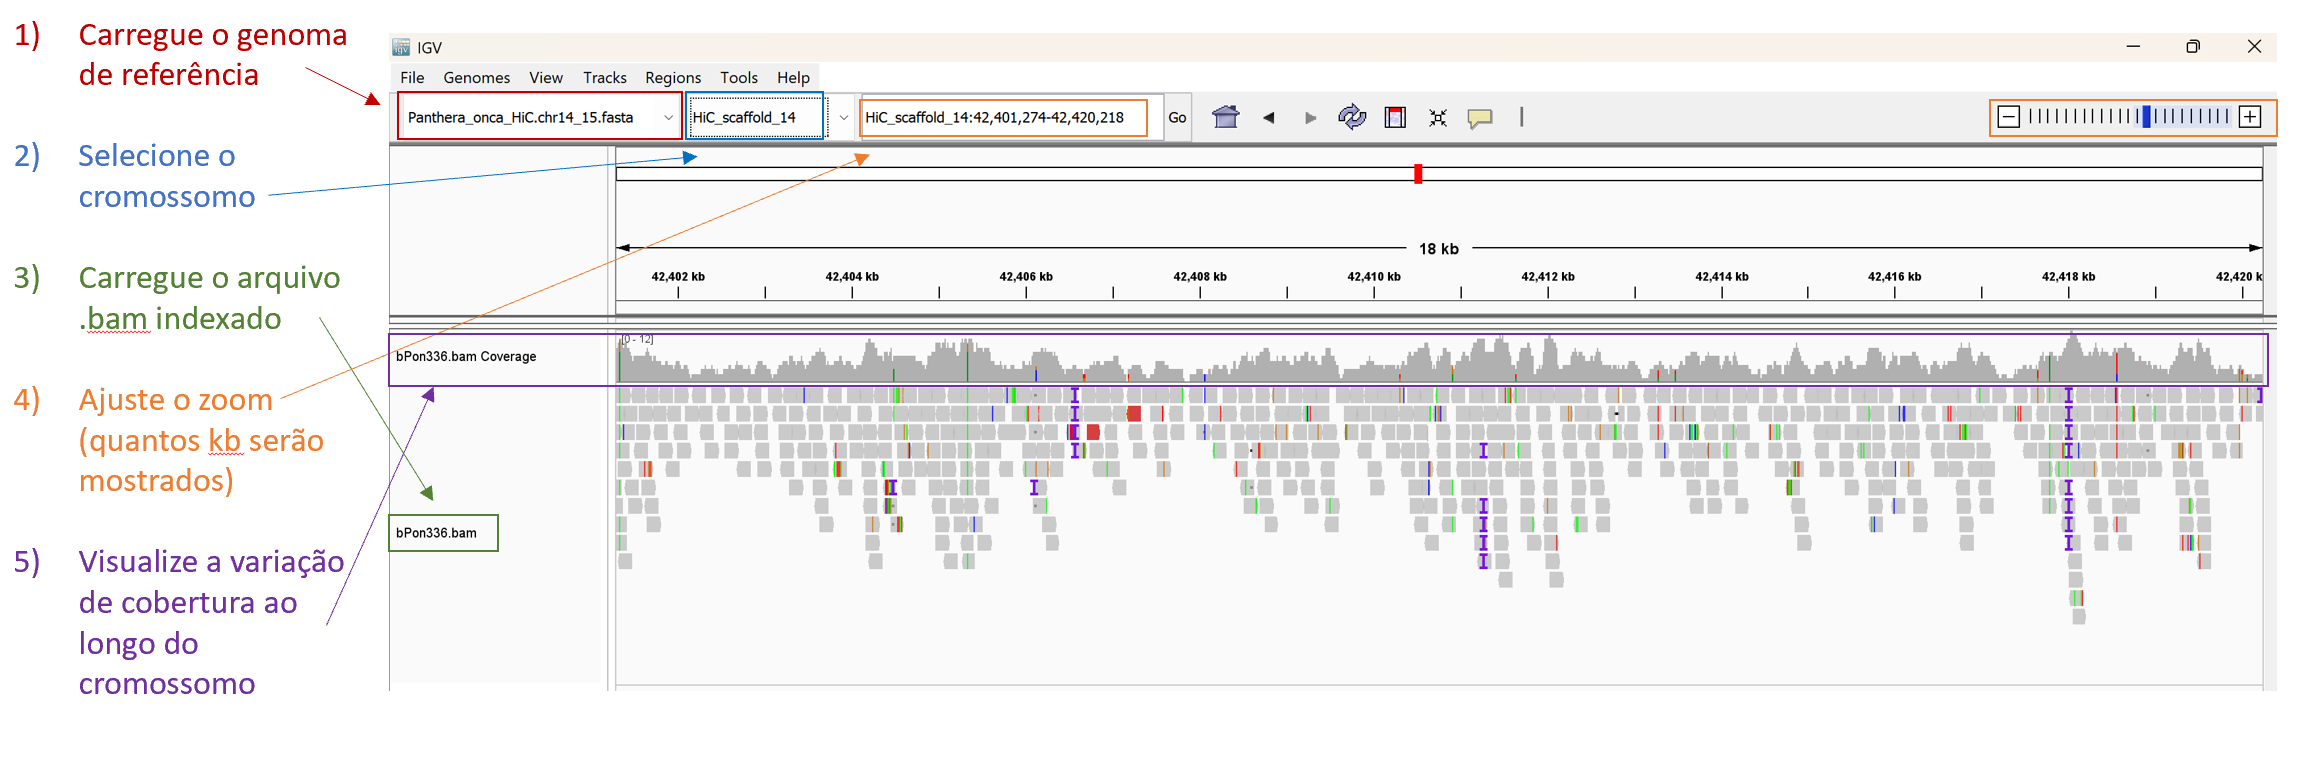

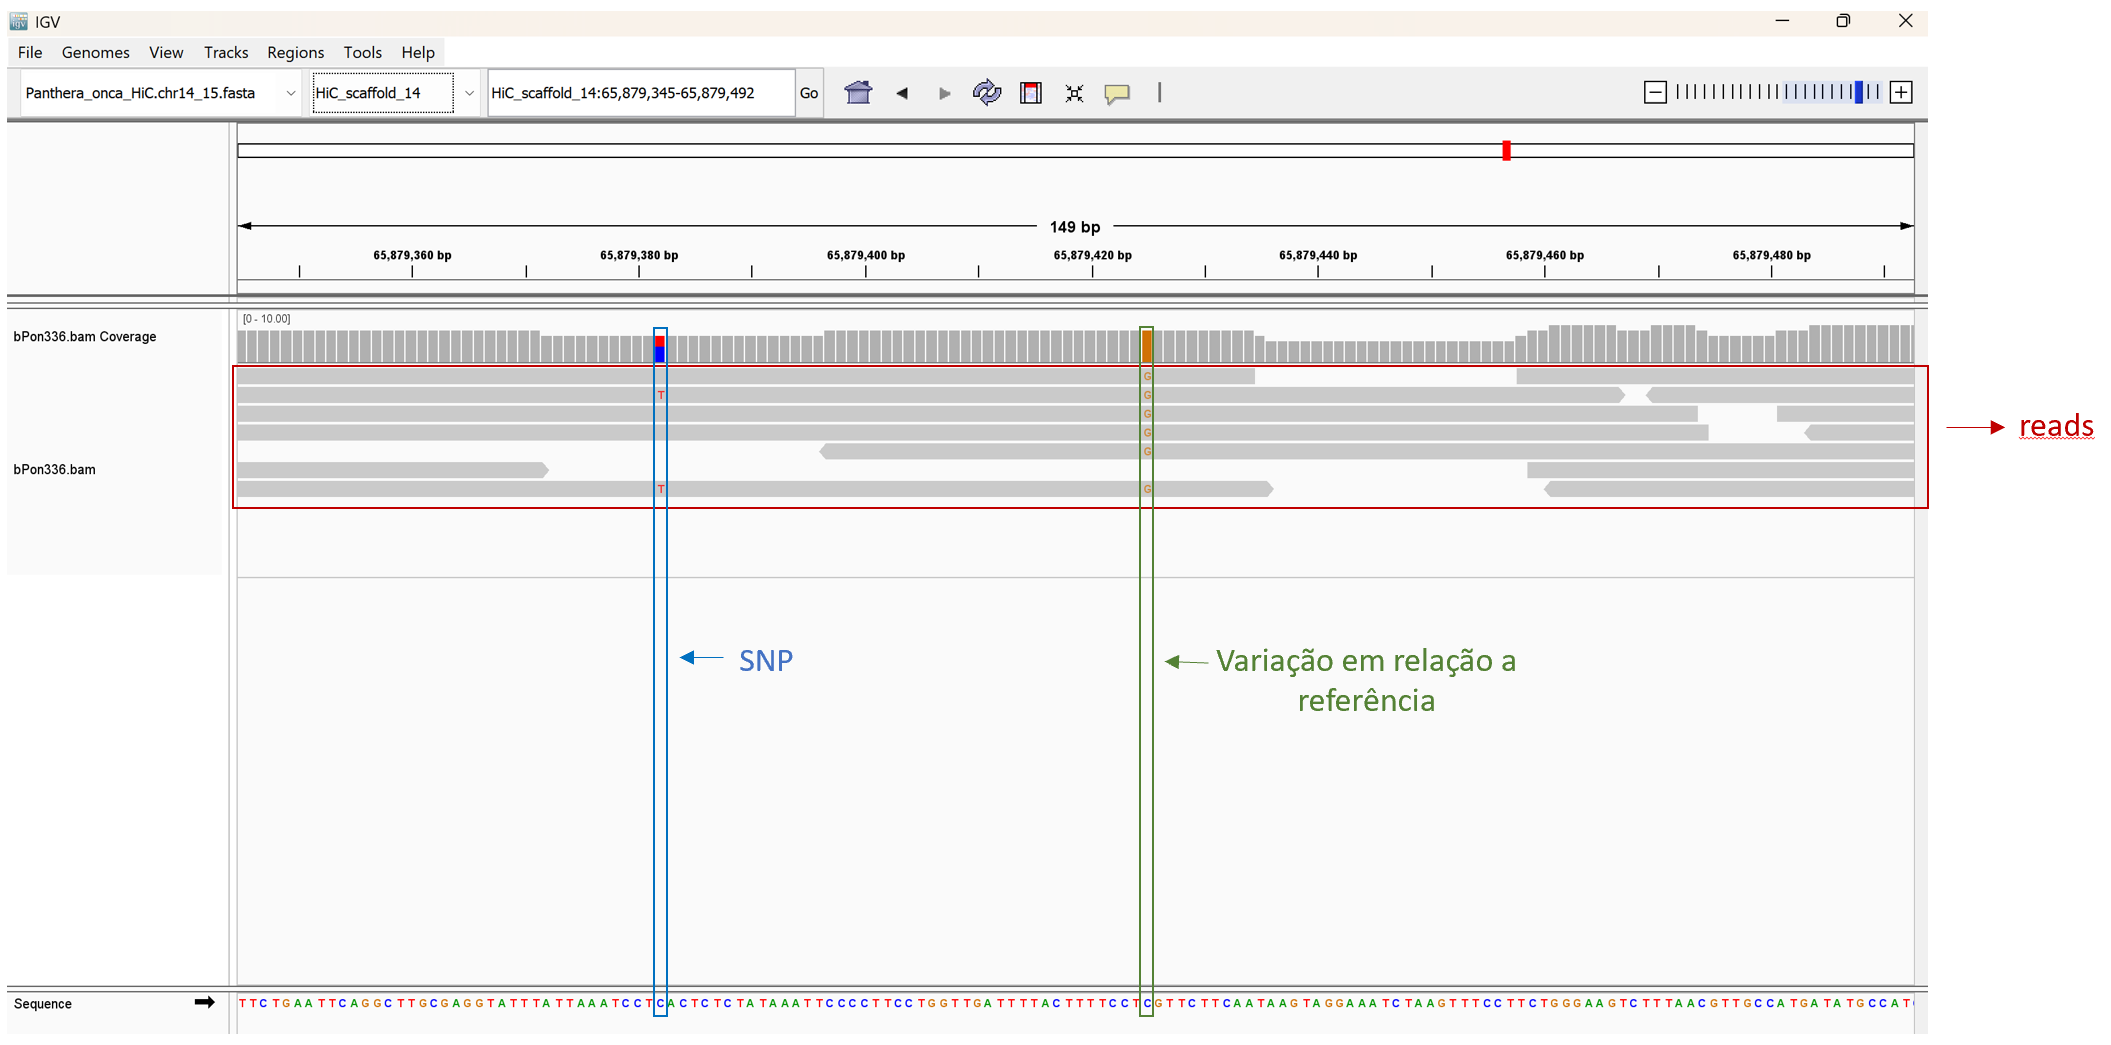

>❓A cobertura é homogênea ao longo do cromossomo ou varia muito? Quais as coberturas das duas posições assinaladas na imagem acima (C/T e G)?